# LambdaMART on LETOR4
### Learning to Rank — Lambda Gradient Approach with GBDT
---
**Dataset**: LETOR4 (MQ2008)  
**Model**: LambdaMART with Optimal Line Search  
**Gradients**: Lambda(λ)  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **LambdaMART**. It uses the exact same $\lambda$-gradients as LambdaRank, but instead of using a neural network, it trains an ensemble of **Gradient Boosted Decision Trees (GBDT)**.

This notebook uses the **Optimal Line Search** for finding the tree weights ($\alpha$). Instead of using a **fixed learning rate** like typical boosting algorithms, we use a path-following algorithm that directly maximizes NDCG by finding exactly where the rank order of documents swaps.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | How LambdaMART and Optimal Line Search works |
| 5    | Model definition using `ltr.lambdamart.LambdaMART` |
| 6    | Training on Fold 1 |
| 7    | Visualizing Training and Optimal Alphas |
| 8    | 5-Fold Evaluation (Standard LETOR Folds) |
| 9    | Feature Importance Analysis |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Pairwise Approaches", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Pairwise Approaches/src")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

In [3]:
# ── Extract MQ2008 dataset ────────────────────────────────────────────────────
# Upload MQ2008.zip to /content/ before running this cell.
import zipfile, os

ZIP_PATH  = "/content/MQ2008.zip"
DATA_PATH = "/content/MQ2008"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data       import load_fold
from ltr.lambdamart import LambdaMART
from ltr.train      import set_seed
from ltr.metrics    import mean_ndcg
from ltr.evaluate   import cross_fold_eval_lambdamart

# ── Global config ─────────────────────────────────────────────────────────────
DATA_PATH = "/content/MQ2008"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)


## Step 4 · Data Loading

In [5]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)


  Fold 1: 471 train | 157 val | 156 test queries


## Step 5 · How LambdaMART & Optimal Line Search Works

LambdaMART replaces the neural network of LambdaRank with an ensemble of **Decision Trees**.
At each iteration $t$, we:
1. We start with base weak ranker which predicts **0** as ouput for every document.
2. Compute the $\lambda_i$ gradients and hessians $w_i$ for all documents using our current model scores $S_t$.
3. Fit a `DecisionTreeRegressor` to predict pseudo-residuals $y_i = -\lambda_i / w_i$ with sample weights $w_i$.
4. Find the optimal combination weight $\alpha$ using an **Exact Line Search**.
5. Update the scores: $S_{t+1} = S_t + \alpha \cdot \text{tree}(X)$

### The Optimal Line Search
Instead of guessing a learning rate (like $\eta=0.1$), we find the $\alpha$ that mathematically maximizes the NDCG.
Because NDCG only changes when documents **swap rank positions**, we can calculate the exact $\alpha$ where any two documents' scores will cross:
$$ S_i + \alpha P_i = S_j + \alpha P_j \implies \alpha = \frac{S_j - S_i}{P_i - P_j} $$

We collect all crossing points for all queries, sort them, and traverse them one by one. At each crossing, we swap the two documents and update the NDCG. Finally, we pick the $\alpha$ that gave the highest overall NDCG.

**Problem**:- Sometimes, more than one pair documents cross each other at crossing point.

**Solution**:-
***Jittering for Degeneracies-*** We add a microscopic random noise ($10^{-9}$) to the initial scores/predictions. This strictly guarantees that no two pairs of documents will ever cross at the same crossing point.

## Step 6 · Model Definition and Training (Fold 1)

In [6]:
set_seed(42)

# Initialize LambdaMART with 100 trees (early stopping may halt earlier)
model = LambdaMART(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

# Train the model. It will print the optimal alpha chosen at each tree.
trained_model, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)


Tree 001 | alpha: 0.1000 | Val NDCG@10: 0.5145  <- best
Tree 002 | alpha: 0.1159 | Val NDCG@10: 0.5267  <- best
Tree 003 | alpha: 0.2179 | Val NDCG@10: 0.5287  <- best
Tree 004 | alpha: 0.1904 | Val NDCG@10: 0.5232
Tree 005 | alpha: 0.3518 | Val NDCG@10: 0.5275
Tree 006 | alpha: 0.5404 | Val NDCG@10: 0.5218
Tree 007 | alpha: 0.5897 | Val NDCG@10: 0.5140
Tree 008 | alpha: 0.7327 | Val NDCG@10: 0.5207
Tree 009 | alpha: 0.6304 | Val NDCG@10: 0.5165
Tree 010 | alpha: 1.0172 | Val NDCG@10: 0.5272
Tree 011 | alpha: 1.0191 | Val NDCG@10: 0.5207
Tree 012 | alpha: 0.8922 | Val NDCG@10: 0.5076
Tree 013 | alpha: 0.7063 | Val NDCG@10: 0.5114
Early stopping at tree 13 (no improvement for 10 trees).


## Step 7 · Visualizing Training & Optimal Alphas

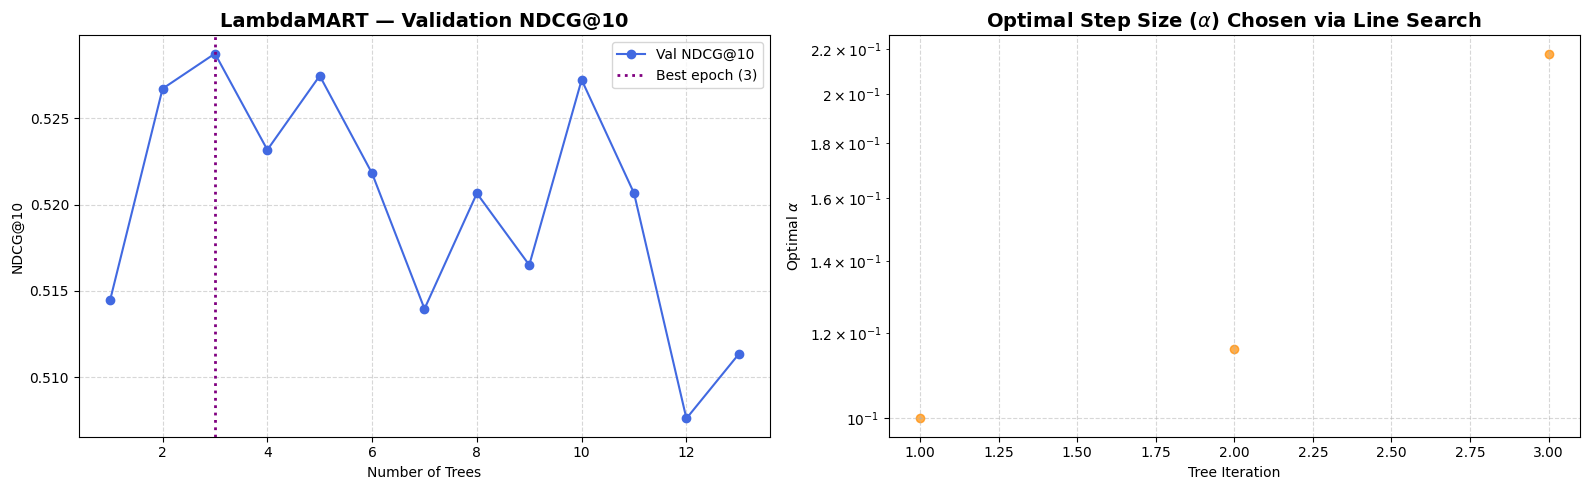

In [8]:
def plot_training_and_alphas(val_ndcg_history, alphas, k=10):
    epochs = range(1, len(val_ndcg_history) + 1)
    best_epoch = val_ndcg_history.index(max(val_ndcg_history)) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: NDCG Convergence
    ax1.plot(epochs, val_ndcg_history, marker="o", color="royalblue", label=f"Val NDCG@{k}")
    ax1.axvline(best_epoch, color="purple", linestyle=":", linewidth=2, label=f"Best epoch ({best_epoch})")
    ax1.set_title(f"LambdaMART — Validation NDCG@{k}", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Number of Trees")
    ax1.set_ylabel(f"NDCG@{k}")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Plot 2: Optimal Alphas
    ax2.scatter(range(1, len(alphas) + 1), alphas, color="darkorange", alpha=0.7)
    ax2.set_title(r"Optimal Step Size ($\alpha$) Chosen via Line Search", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Tree Iteration")
    ax2.set_ylabel(r"Optimal $\alpha$")
    ax2.set_yscale("log") # Log scale since alphas can vary greatly
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_training_and_alphas(val_ndcg_history, trained_model.alphas)


## Training Results — Fold 1

- The model has the highest NDCG at Tree iteration 3 itself. That means the model saturated by tree 3.
- $\alpha$ increases with the tree iteration which means the trees that adapted from the weak rankers have more priority than the weak rankers

## Step 8 · 5-Fold Cross Validation

Running the full benchmark across all 5 folds using 3 random seeds per fold.

In [9]:
# We'll use 50 trees to keep the benchmark run reasonably fast.
def lambdamart_factory():
    return LambdaMART(
        n_estimators=50,
        max_depth=6,
        min_samples_leaf=20,
        patience=10
    )

results = cross_fold_eval_lambdamart(
    model_fn=lambdamart_factory,
    base_path=DATA_PATH,
    folds=(1, 2, 3, 4, 5),
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    verbose=False,
)



═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════


  Fold 1: 471 train | 157 val | 156 test queries
  NDCG@1  : 0.3262 ± 0.0061
  NDCG@3  : 0.3830 ± 0.0020
  NDCG@5  : 0.4256 ± 0.0070
  NDCG@10 : 0.4682 ± 0.0020

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════


  Fold 2: 471 train | 156 val | 157 test queries
  NDCG@1  : 0.3100 ± 0.0000
  NDCG@3  : 0.3522 ± 0.0000
  NDCG@5  : 0.3880 ± 0.0000
  NDCG@10 : 0.4411 ± 0.0001

═══════════════════════════════════════════════════════
  FOLD 3 / 5
═══════════════════════════════════════════════════════


  Fold 3: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3213 ± 0.0187
  NDCG@3  : 0.3556 ± 0.0194
  NDCG@5  : 0.4007 ± 0.0188
  NDCG@10 : 0.4558 ± 0.0097

═══════════════════════════════════════════════════════
  FOLD 4 / 5
═══════════════════════════════════════════════════════


  Fold 4: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3744 ± 0.0080
  NDCG@3  : 0.4271 ± 0.0153
  NDCG@5  : 0.4746 ± 0.0064
  NDCG@10 : 0.5268 ± 0.0071

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════


  Fold 5: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3843 ± 0.0079
  NDCG@3  : 0.4313 ± 0.0031
  NDCG@5  : 0.4833 ± 0.0042
  NDCG@10 : 0.5312 ± 0.0013

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDAMART)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.3432 ± 0.0318
  NDCG@3  : 0.3898 ± 0.0357
  NDCG@5  : 0.4344 ± 0.0396
  NDCG@10 : 0.4846 ± 0.0377
═══════════════════════════════════════════════════════



## 5-Fold Cross validation results:
- Folds 4 and 5 are noticeably better than 1, 2, and 3. NDCG@10 jumps from ~0.44–0.47 in the first three folds to ~0.52–0.53 in the last two.
- **Low Variance** across the three seeds - GB Trees usually have low variance across seeds because the seed affects only some of the trees but we taking a weightted sum across trees which makes the output to converge to a closer value.
- **Near-Zero variance for Fold 2** - The training data might not have tie breaks in it so the seed doesn't effect the final model and it is same across all seeds.

## Step 9 · Feature Importances

Because LambdaMART uses Decision Trees, we can directly compute the importance of each of the 46 features by averaging the `feature_importances_` across all trees in the ensemble.

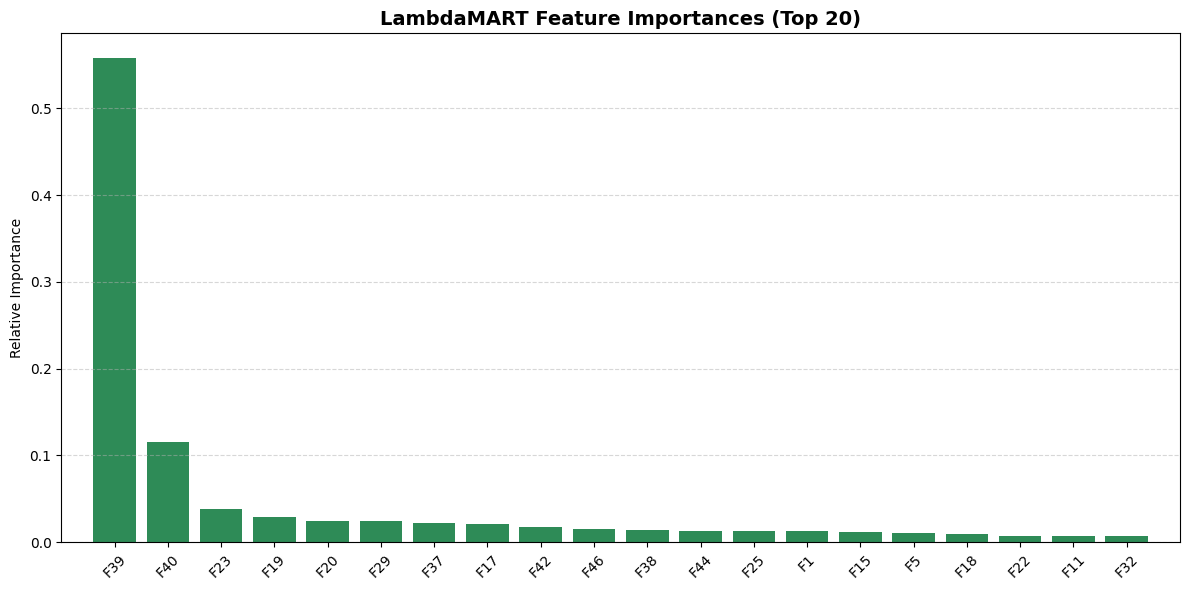

In [10]:
def plot_feature_importances(model, num_features=46):
    importances = np.zeros(num_features)
    for tree in model.trees:
        importances += tree.feature_importances_
    importances /= len(model.trees)

    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 6))
    plt.title("LambdaMART Feature Importances (Top 20)", fontsize=14, fontweight="bold")
    plt.bar(range(20), importances[indices][:20], color="seagreen", align="center")
    plt.xticks(range(20), [f"F{i+1}" for i in indices[:20]], rotation=45)
    plt.xlim([-1, 20])
    plt.ylabel("Relative Importance")
    plt.grid(axis='y', linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_feature_importances(trained_model)


## Feature Imortance results-
- F39 Dominates every other feature with a very high relative importance. This might be the BM25 or TF-IDf score

In [11]:
import json
import os
import numpy as np

# Create the results directory if it doesn't exist
os.makedirs("/content/ltr_results", exist_ok=True)

# Helper function to convert numpy floats/ints to standard python types for JSON
def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

# Save the LambdaMART results dictionary to a JSON file
with open("/content/ltr_results/lambdamart_results.json", "w") as f:
    json.dump(to_serialisable(results), f, indent=2)

print("Results saved to /content/ltr_results/lambdamart_results.json")

Results saved to /content/ltr_results/lambdamart_results.json
